
# RL Course Project — Multi-Product Inventory Control
## Standalone Training, Validation and Export Notebook

This notebook is intentionally **standalone**. It does **not** import any project-local modules such as `src.common`, `train_all.py`, or `evaluate_all.py`.

The only project-specific dependency is the **official course-provided** `industrial_inventory_env` package. All preprocessing, model definitions, training loops, evaluation code, plots, result tables, and submission-policy export logic are contained in this notebook.

### Five distinct RL techniques
1. Tabular Q-Learning
2. REINFORCE with learned baseline
3. Advantage Actor-Critic (A2C)
4. Proximal Policy Optimization (PPO)
5. Double DQN with factorized product-wise Q heads

### Submission interface
Training uses internal action indices `[0, ..., 10]` for each product. Exported `run_policy(observation)` functions return actual quantities `[0, 10, ..., 100]`.


## 1. Imports and reproducibility

In [1]:

import os
import json
import math
import random
import shutil
import importlib.util
from pathlib import Path
from dataclasses import dataclass
from collections import deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from torch.utils.data import TensorDataset, DataLoader

# Official course package
from industrial_inventory_env import IndustrialInventoryEnv, generate_student_config

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


## 2. Assigned parameter variant and configuration

In [3]:

ROLL_NUMBER = 'DA25M609'
student_config = generate_student_config(ROLL_NUMBER)

print("Generated assigned configuration:")
print(student_config)

if isinstance(student_config, dict):
    if "variant_id" in student_config:
        print("variant_id:", student_config["variant_id"])
    if "config_fingerprint" in student_config:
        print("config_fingerprint:", student_config["config_fingerprint"])


Generated assigned configuration:
{'project_version': 'IITM-6002W-RL-Inventory-2026-v1', 'roll_number': 'DA25M609', 'variant_id': 'V027', 'demand_multiplier_profile': [1.0, 0.95, 1.05], 'initial_inventory_profile': [80, 100, 120], 'lead_time_delay_profile': [0.05, 0.1, 0.0], 'declared_ranges': {'demand_multiplier': [0.85, 1.15], 'initial_inventory': [80, 120], 'lead_time_delay_probability': [0.0, 0.1]}, 'config_fingerprint': 'c40bc200a44653e1'}
variant_id: V027
config_fingerprint: c40bc200a44653e1



## 3. Common state preprocessing and action mapping

The environment provides:
- current inventory for 3 products,
- a 3×4 arrival pipeline,
- 7×3 demand history,
- current day,
- capacity utilisation.

The neural policies use a **56-dimensional** feature vector containing both raw observations and inventory-control-derived features. Recent demand receives larger weights so the models can react faster to trend and shock scenarios.

Training action indices are `[0, ..., 10]`. The submission quantity mapping is:

\[
q_i = 10 a_i
\]


In [4]:

REFERENCE_DEMAND = np.array([30.0, 25.0, 35.0], dtype=np.float32)
LEAD_TIMES = np.array([3.0, 2.0, 1.0], dtype=np.float32)
PRODUCT_VOLUMES = np.array([2.0, 3.0, 1.5], dtype=np.float32)
CAPACITY = 1000.0

def action_indices_to_quantities(action):
    action = np.asarray(action, dtype=np.int64)
    return (action * 10).astype(int).tolist()

def quantities_to_action_indices(quantities):
    q = np.asarray(quantities, dtype=np.int64)
    if np.any(q < 0) or np.any(q > 100) or np.any(q % 10 != 0):
        raise ValueError("Quantities must belong to {0,10,...,100}")
    return (q // 10).astype(np.int64)

def demand_estimate(observation):
    hist = np.asarray(observation["demand_history"], dtype=np.float32)
    weights = np.array([0.05, 0.07, 0.10, 0.13, 0.17, 0.21, 0.27], dtype=np.float32)

    estimates = np.empty(3, dtype=np.float32)
    for p in range(3):
        vals = hist[:, p]
        mask = vals > 0

        if not np.any(mask):
            estimates[p] = REFERENCE_DEMAND[p]
            continue

        w = weights[mask]
        w = w / w.sum()
        recent = float(np.dot(vals[mask], w))
        confidence = min(int(mask.sum()), 7) / 7.0
        estimates[p] = confidence * recent + (1.0 - confidence) * REFERENCE_DEMAND[p]

    return np.maximum(estimates, 1.0)

def encode_observation(observation):
    inventory = np.asarray(observation["inventory"], dtype=np.float32)
    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float32)
    demand_hist = np.asarray(observation["demand_history"], dtype=np.float32)

    day = float(np.asarray(observation["day"]).reshape(-1)[0])
    util = float(np.asarray(observation["capacity_utilisation"]).reshape(-1)[0])

    d_hat = demand_estimate(observation)
    inv_pos = inventory + pipeline.sum(axis=1)
    days_supply = inv_pos / np.maximum(d_hat, 1.0)
    lead_demand = d_hat * LEAD_TIMES
    gap = lead_demand - inv_pos
    next_arrivals = pipeline[:, 0]

    raw = np.concatenate([
        inventory / 150.0,                    # 3
        pipeline.flatten() / 100.0,          # 12
        demand_hist.flatten() / 80.0,        # 21
        np.array([day / 50.0, util]),         # 2
        d_hat / 60.0,                         # 3
        inv_pos / 250.0,                      # 3
        days_supply / 6.0,                    # 3
        lead_demand / 180.0,                  # 3
        gap / 180.0,                          # 3
        next_arrivals / 100.0,                # 3
    ]).astype(np.float32)

    assert raw.shape == (56,), raw.shape
    return raw

INPUT_DIM = 56

def base_stock_fallback(observation):
    inventory = np.asarray(observation["inventory"], dtype=np.float32)
    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float32)
    d_hat = demand_estimate(observation)

    inv_pos = inventory + pipeline.sum(axis=1)
    target = d_hat * (LEAD_TIMES + 0.75)
    need = np.maximum(target - inv_pos, 0.0)
    qty = np.clip(np.ceil(need / 10.0) * 10.0, 0, 100)

    return (qty / 10.0).astype(np.int64)

def make_env(config, scenario_mode="random"):
    return IndustrialInventoryEnv(
        config,
        scenario_mode=scenario_mode,
        domain_randomization=True
    )


## 4. Shared neural-network architectures

In [5]:

class ActorCriticNet(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
        )
        self.actor = nn.Linear(hidden, 33)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.body(x)
        logits = self.actor(h).view(-1, 3, 11)
        value = self.critic(h).squeeze(-1)
        return logits, value

class ReinforceNet(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
        )
        self.actor = nn.Linear(hidden, 33)
        self.baseline = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.body(x)
        logits = self.actor(h).view(-1, 3, 11)
        baseline = self.baseline(h).squeeze(-1)
        return logits, baseline

class FactorizedQNetwork(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.head = nn.Linear(hidden, 33)

    def forward(self, x):
        h = self.body(x)
        return self.head(h).view(-1, 3, 11)


## 5. Tabular Q-Learning

In [6]:

def tabular_state(observation):
    inventory = np.asarray(observation["inventory"], dtype=np.float32)
    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float32)
    d_hat = demand_estimate(observation)

    inv_pos = inventory + pipeline.sum(axis=1)
    gap = d_hat * LEAD_TIMES - inv_pos

    inv_bins = np.clip((inventory // 20).astype(int), 0, 8)
    pos_bins = np.clip((inv_pos // 30).astype(int), 0, 10)
    gap_bins = np.clip(((gap + 180) // 30).astype(int), 0, 12)

    return tuple(np.concatenate([inv_bins, pos_bins, gap_bins]).tolist())

def train_tabular_q(config, episodes=12000, alpha=0.08, gamma=0.99,
                    eps_start=1.0, eps_end=0.05, eps_decay=0.9995):
    Q = defaultdict(lambda: np.zeros((3, 11), dtype=np.float32))
    returns = []
    eps = eps_start

    for ep in range(episodes):
        env = make_env(config, scenario_mode="random")
        obs, _ = env.reset(seed=SEED + ep)
        total_reward = 0.0

        while True:
            s = tabular_state(obs)

            if np.random.rand() < eps:
                action = np.random.randint(0, 11, size=3)
            else:
                action = np.argmax(Q[s], axis=1)

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += float(reward)

            ns = tabular_state(next_obs)
            for p in range(3):
                target = float(reward)
                if not done:
                    target += gamma * np.max(Q[ns][p])
                Q[s][p, action[p]] += alpha * (target - Q[s][p, action[p]])

            obs = next_obs
            if done:
                break

        eps = max(eps_end, eps * eps_decay)
        returns.append(total_reward)

        if (ep + 1) % 1000 == 0:
            print(f"Tabular Q episode {ep+1}/{episodes}, "
                  f"mean return(last100)={np.mean(returns[-100:]):.2f}, eps={eps:.3f}")

    return dict(Q), returns


## 6. REINFORCE with learned baseline

In [7]:

def discounted_returns(rewards, gamma):
    out = []
    g = 0.0
    for r in reversed(rewards):
        g = r + gamma * g
        out.append(g)
    return torch.tensor(list(reversed(out)), dtype=torch.float32, device=DEVICE)

def train_reinforce(config, episodes=8000, gamma=0.99, lr=2e-4,
                    hidden=256, entropy_coef=0.005, reward_scale=0.1):
    net = ReinforceNet(hidden=hidden).to(DEVICE)
    opt = optim.Adam(net.parameters(), lr=lr)
    history = []

    for ep in range(episodes):
        env = make_env(config, scenario_mode="random")
        obs, _ = env.reset(seed=100000 + ep)

        logps, baselines, entropies, rewards = [], [], [], []
        raw_total = 0.0

        while True:
            x = torch.from_numpy(encode_observation(obs)).unsqueeze(0).to(DEVICE)
            logits, baseline = net(x)
            dist = Categorical(logits=logits.squeeze(0))

            action = dist.sample()
            next_obs, reward, terminated, truncated, _ = env.step(
                action.detach().cpu().numpy()
            )

            logps.append(dist.log_prob(action).sum())
            entropies.append(dist.entropy().sum())
            baselines.append(baseline.squeeze(0))

            rewards.append(float(reward) * reward_scale)
            raw_total += float(reward)

            obs = next_obs
            if terminated or truncated:
                break

        R = discounted_returns(rewards, gamma)
        V = torch.stack(baselines)
        logp = torch.stack(logps)
        entropy = torch.stack(entropies)

        adv = R - V
        adv_norm = (adv - adv.mean()) / (adv.std(unbiased=False) + 1e-8)

        actor_loss = -(logp * adv_norm.detach()).mean()
        value_loss = 0.5 * adv.pow(2).mean()
        loss = actor_loss + value_loss - entropy_coef * entropy.mean()

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 0.5)
        opt.step()

        history.append(raw_total)

        if (ep + 1) % 500 == 0:
            print(f"REINFORCE episode {ep+1}/{episodes}, "
                  f"mean return(last100)={np.mean(history[-100:]):.2f}")

    return net, history


## 7. Advantage Actor-Critic (A2C)

In [8]:

def train_a2c(config, total_steps=600_000, n_steps=32, gamma=0.99,
              lr=2e-4, hidden=256, entropy_coef=0.005,
              value_coef=0.5, reward_scale=0.1):
    net = ActorCriticNet(hidden=hidden).to(DEVICE)
    opt = optim.Adam(net.parameters(), lr=lr)

    env = make_env(config, scenario_mode="random")
    obs, _ = env.reset(seed=200001)

    steps = 0
    episode_return = 0.0
    episode_returns = []

    while steps < total_steps:
        states, actions, rewards, dones, values, logps, entropies = [], [], [], [], [], [], []

        for _ in range(n_steps):
            x = torch.from_numpy(encode_observation(obs)).unsqueeze(0).to(DEVICE)
            logits, value = net(x)
            dist = Categorical(logits=logits.squeeze(0))
            action = dist.sample()

            next_obs, reward, terminated, truncated, _ = env.step(
                action.detach().cpu().numpy()
            )
            done = terminated or truncated

            states.append(x.squeeze(0))
            actions.append(action)
            rewards.append(float(reward) * reward_scale)
            dones.append(float(done))
            values.append(value.squeeze(0))
            logps.append(dist.log_prob(action).sum())
            entropies.append(dist.entropy().sum())

            episode_return += float(reward)
            steps += 1
            obs = next_obs

            if done:
                episode_returns.append(episode_return)
                episode_return = 0.0
                env = make_env(config, scenario_mode="random")
                obs, _ = env.reset(seed=200001 + steps)

            if steps >= total_steps:
                break

        with torch.no_grad():
            x = torch.from_numpy(encode_observation(obs)).unsqueeze(0).to(DEVICE)
            _, bootstrap = net(x)
            bootstrap = bootstrap.squeeze(0)

        returns = []
        R = bootstrap
        for r, d in zip(reversed(rewards), reversed(dones)):
            R = torch.tensor(r, device=DEVICE) + gamma * R * (1.0 - d)
            returns.append(R)
        returns = torch.stack(list(reversed(returns)))

        values_t = torch.stack(values)
        logps_t = torch.stack(logps)
        ent_t = torch.stack(entropies)

        adv = returns - values_t
        adv_norm = (adv - adv.mean()) / (adv.std(unbiased=False) + 1e-8)

        actor_loss = -(logps_t * adv_norm.detach()).mean()
        value_loss = 0.5 * adv.pow(2).mean()
        loss = actor_loss + value_coef * value_loss - entropy_coef * ent_t.mean()

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 0.5)
        opt.step()

        if steps % 50_000 < n_steps and episode_returns:
            print(f"A2C step {steps}/{total_steps}, "
                  f"mean return(last50)={np.mean(episode_returns[-50:]):.2f}")

    return net, episode_returns


## 8. Proximal Policy Optimization (PPO)

In [9]:

def train_ppo(config, total_steps=1_000_000, rollout_steps=2048,
              epochs=10, batch_size=256, gamma=0.99, gae_lambda=0.95,
              clip_ratio=0.20, lr=1e-4, hidden=256, value_coef=0.5,
              entropy_coef=0.01, reward_scale=0.1):
    net = ActorCriticNet(hidden=hidden).to(DEVICE)
    opt = optim.Adam(net.parameters(), lr=lr)

    env = make_env(config, scenario_mode="random")
    obs, _ = env.reset(seed=300001)

    total = 0
    episode_return = 0.0
    episode_returns = []

    while total < total_steps:
        states, actions, rewards, dones, old_logps, values = [], [], [], [], [], []

        for _ in range(min(rollout_steps, total_steps - total)):
            state_np = encode_observation(obs)
            x = torch.from_numpy(state_np).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                logits, value = net(x)
                dist = Categorical(logits=logits.squeeze(0))
                action = dist.sample()
                logp = dist.log_prob(action).sum()

            next_obs, reward, terminated, truncated, _ = env.step(
                action.cpu().numpy()
            )
            done = terminated or truncated

            states.append(state_np)
            actions.append(action.cpu().numpy())
            rewards.append(float(reward) * reward_scale)
            dones.append(float(done))
            old_logps.append(float(logp.cpu()))
            values.append(float(value.item()))

            episode_return += float(reward)
            total += 1
            obs = next_obs

            if done:
                episode_returns.append(episode_return)
                episode_return = 0.0
                env = make_env(config, scenario_mode="random")
                obs, _ = env.reset(seed=300001 + total)

        with torch.no_grad():
            x = torch.from_numpy(encode_observation(obs)).unsqueeze(0).to(DEVICE)
            _, next_value_t = net(x)
            next_value = float(next_value_t.item())

        rewards_np = np.asarray(rewards, dtype=np.float32)
        dones_np = np.asarray(dones, dtype=np.float32)
        values_np = np.asarray(values, dtype=np.float32)

        advantages = np.zeros_like(rewards_np)
        gae = 0.0

        for t in reversed(range(len(rewards_np))):
            nv = next_value if t == len(rewards_np) - 1 else values_np[t + 1]
            nonterminal = 1.0 - dones_np[t]
            delta = rewards_np[t] + gamma * nv * nonterminal - values_np[t]
            gae = delta + gamma * gae_lambda * nonterminal * gae
            advantages[t] = gae

        returns = advantages + values_np
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        S = torch.tensor(np.asarray(states), dtype=torch.float32)
        A = torch.tensor(np.asarray(actions), dtype=torch.long)
        OL = torch.tensor(old_logps, dtype=torch.float32)
        ADV = torch.tensor(advantages, dtype=torch.float32)
        RET = torch.tensor(returns, dtype=torch.float32)

        ds = TensorDataset(S, A, OL, ADV, RET)

        progress = total / total_steps
        current_entropy = entropy_coef * (1.0 - 0.9 * progress)

        for _ in range(epochs):
            loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

            for s_b, a_b, old_b, adv_b, ret_b in loader:
                s_b = s_b.to(DEVICE)
                a_b = a_b.to(DEVICE)
                old_b = old_b.to(DEVICE)
                adv_b = adv_b.to(DEVICE)
                ret_b = ret_b.to(DEVICE)

                logits, value = net(s_b)
                dist = Categorical(logits=logits)

                new_logp = dist.log_prob(a_b).sum(dim=1)
                entropy = dist.entropy().sum(dim=1).mean()

                ratio = torch.exp(new_logp - old_b)
                obj1 = ratio * adv_b
                obj2 = torch.clamp(ratio, 1.0 - clip_ratio, 1.0 + clip_ratio) * adv_b

                actor_loss = -torch.min(obj1, obj2).mean()
                value_loss = 0.5 * (value - ret_b).pow(2).mean()

                loss = actor_loss + value_coef * value_loss - current_entropy * entropy

                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(), 0.5)
                opt.step()

        if total % 50_000 < rollout_steps and episode_returns:
            print(f"PPO step {total}/{total_steps}, "
                  f"mean return(last50)={np.mean(episode_returns[-50:]):.2f}")

    return net, episode_returns


## 9. Double DQN with factorized Q heads

In [10]:

@dataclass
class Transition:
    state: np.ndarray
    action: np.ndarray
    reward: float
    next_state: np.ndarray
    done: float

def gather_factorized_q(q_values, actions):
    # q_values: [B, 3, 11], actions: [B, 3]
    return q_values.gather(2, actions.unsqueeze(-1)).squeeze(-1).sum(dim=1)

def train_double_dqn(config, total_steps=700_000, batch_size=256,
                     gamma=0.99, lr=2e-4, hidden=256,
                     replay_size=100_000, learning_starts=10_000,
                     target_update=2500, reward_scale=0.1):
    online = FactorizedQNetwork(hidden=hidden).to(DEVICE)
    target = FactorizedQNetwork(hidden=hidden).to(DEVICE)
    target.load_state_dict(online.state_dict())
    target.eval()

    opt = optim.Adam(online.parameters(), lr=lr)
    replay = deque(maxlen=replay_size)

    env = make_env(config, scenario_mode="random")
    obs, _ = env.reset(seed=400001)

    episode_return = 0.0
    episode_returns = []

    for step in range(total_steps):
        eps = max(0.05, 1.0 - 0.95 * step / max(total_steps * 0.6, 1))

        state = encode_observation(obs)

        if np.random.rand() < eps:
            action = np.random.randint(0, 11, size=3, dtype=np.int64)
        else:
            with torch.no_grad():
                q = online(torch.from_numpy(state).unsqueeze(0).to(DEVICE))[0]
                action = q.argmax(dim=1).cpu().numpy().astype(np.int64)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = encode_observation(next_obs)

        replay.append(Transition(
            state=state,
            action=action.copy(),
            reward=float(reward) * reward_scale,
            next_state=next_state,
            done=float(done)
        ))

        episode_return += float(reward)
        obs = next_obs

        if done:
            episode_returns.append(episode_return)
            episode_return = 0.0
            env = make_env(config, scenario_mode="random")
            obs, _ = env.reset(seed=400001 + step)

        if step >= learning_starts and len(replay) >= batch_size:
            batch = random.sample(replay, batch_size)

            s = torch.tensor(np.asarray([b.state for b in batch]), dtype=torch.float32, device=DEVICE)
            a = torch.tensor(np.asarray([b.action for b in batch]), dtype=torch.long, device=DEVICE)
            r = torch.tensor([b.reward for b in batch], dtype=torch.float32, device=DEVICE)
            ns = torch.tensor(np.asarray([b.next_state for b in batch]), dtype=torch.float32, device=DEVICE)
            d = torch.tensor([b.done for b in batch], dtype=torch.float32, device=DEVICE)

            q = gather_factorized_q(online(s), a)

            with torch.no_grad():
                next_actions = online(ns).argmax(dim=2)
                next_q = gather_factorized_q(target(ns), next_actions)
                y = r + gamma * (1.0 - d) * next_q

            loss = nn.functional.smooth_l1_loss(q, y)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(online.parameters(), 1.0)
            opt.step()

        if step > 0 and step % target_update == 0:
            target.load_state_dict(online.state_dict())

        if step > 0 and step % 50_000 == 0 and episode_returns:
            print(f"Double DQN step {step}/{total_steps}, "
                  f"mean return(last50)={np.mean(episode_returns[-50:]):.2f}, eps={eps:.3f}")

    return online, episode_returns


## 10. Train all five techniques

In [ ]:

ARTIFACT_DIR = Path("artifacts")
SUBMISSION_DIR = Path("submissions")
ARTIFACT_DIR.mkdir(exist_ok=True)
SUBMISSION_DIR.mkdir(exist_ok=True)

# Set True only for a quick execution test.
SMOKE_TEST = False

if SMOKE_TEST:
    q_episodes = 50
    reinforce_episodes = 20
    a2c_steps = 2_000
    ppo_steps = 4_000
    ddqn_steps = 4_000
else:
    q_episodes = 12_000
    reinforce_episodes = 8_000
    a2c_steps = 600_000
    ppo_steps = 1_000_000
    ddqn_steps = 700_000

print("1/5 Training Tabular Q-Learning")
tabular_q, hist_tabular = train_tabular_q(student_config, episodes=q_episodes)
np.savez_compressed(
    ARTIFACT_DIR / "tabular_q.npz",
    states=np.array(list(tabular_q.keys()), dtype=object),
    values=np.array(list(tabular_q.values()), dtype=object)
)

print("2/5 Training REINFORCE")
reinforce_net, hist_reinforce = train_reinforce(student_config, episodes=reinforce_episodes)
torch.save(reinforce_net.state_dict(), ARTIFACT_DIR / "reinforce.pt")

print("3/5 Training A2C")
a2c_net, hist_a2c = train_a2c(student_config, total_steps=a2c_steps)
torch.save(a2c_net.state_dict(), ARTIFACT_DIR / "a2c.pt")

print("4/5 Training PPO")
ppo_net, hist_ppo = train_ppo(student_config, total_steps=ppo_steps)
torch.save(ppo_net.state_dict(), ARTIFACT_DIR / "ppo.pt")

print("5/5 Training Double DQN")
ddqn_net, hist_ddqn = train_double_dqn(student_config, total_steps=ddqn_steps)
torch.save(ddqn_net.state_dict(), ARTIFACT_DIR / "double_dqn.pt")

print("Training complete.")


## 11. Learning curves / convergence evidence

In [11]:

def rolling_mean(x, window=100):
    s = pd.Series(x, dtype=float)
    return s.rolling(window, min_periods=1).mean().to_numpy()

training_histories = {
    "Tabular Q": hist_tabular,
    "REINFORCE": hist_reinforce,
    "A2C": hist_a2c,
    "PPO": hist_ppo,
    "Double DQN": hist_ddqn,
}

for name, hist in training_histories.items():
    plt.figure(figsize=(8, 4))
    plt.plot(rolling_mean(hist, 100))
    plt.title(f"{name} — Rolling Mean Episode Return")
    plt.xlabel("Episode")
    plt.ylabel("Environment Return")
    plt.grid(alpha=0.25)
    plt.show()


NameError: name 'hist_tabular' is not defined


## 12. Load trained model artefacts

This section allows the notebook to be reopened later and used **without retraining**.  
It loads the five frozen artefacts from `artifacts/` and reconstructs the corresponding policy objects.

Expected artefacts:

| Technique | Artefact |
|---|---|
| Tabular Q-Learning | `artifacts/tabular_q.npz` |
| REINFORCE + baseline | `artifacts/reinforce.pt` |
| A2C | `artifacts/a2c.pt` |
| PPO | `artifacts/ppo.pt` |
| Double DQN | `artifacts/double_dqn.pt` |

Run this section instead of the training section when the final trained artefacts already exist.


In [13]:

ARTIFACT_DIR = Path("artifacts")

def load_tabular_q_artifact(path=ARTIFACT_DIR / "tabular_q.npz"):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing artefact: {path}")

    data = np.load(path, allow_pickle=True)
    states = data["states"]
    values = data["values"]
    table = {tuple(s): v for s, v in zip(states, values)}

    print(f"Loaded Tabular Q table from {path} with {len(table):,} states")
    return table

def load_reinforce_artifact(path=ARTIFACT_DIR / "reinforce.pt", hidden=256):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing artefact: {path}")

    model = ReinforceNet(hidden=hidden).to(DEVICE)
    state_dict = torch.load(path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()

    print(f"Loaded REINFORCE model from {path}")
    return model

def load_a2c_artifact(path=ARTIFACT_DIR / "a2c.pt", hidden=256):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing artefact: {path}")

    model = ActorCriticNet(hidden=hidden).to(DEVICE)
    state_dict = torch.load(path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()

    print(f"Loaded A2C model from {path}")
    return model

def load_ppo_artifact(path=ARTIFACT_DIR / "ppo.pt", hidden=256):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing artefact: {path}")

    model = ActorCriticNet(hidden=hidden).to(DEVICE)
    state_dict = torch.load(path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()

    print(f"Loaded PPO model from {path}")
    return model

def load_double_dqn_artifact(path=ARTIFACT_DIR / "double_dqn.pt", hidden=256):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing artefact: {path}")

    model = FactorizedQNetwork(hidden=hidden).to(DEVICE)
    state_dict = torch.load(path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()

    print(f"Loaded Double DQN model from {path}")
    return model

def load_all_artifacts():
    loaded = {
        "tabular_q": load_tabular_q_artifact(),
        "reinforce": load_reinforce_artifact(),
        "a2c": load_a2c_artifact(),
        "ppo": load_ppo_artifact(),
        "double_dqn": load_double_dqn_artifact(),
    }
    return loaded

# Uncomment this block when you want to restore saved models without retraining:
#
loaded_models = load_all_artifacts()
tabular_q = loaded_models["tabular_q"]
reinforce_net = loaded_models["reinforce"]
a2c_net = loaded_models["a2c"]
ppo_net = loaded_models["ppo"]
ddqn_net = loaded_models["double_dqn"]


Loaded Tabular Q table from artifacts\tabular_q.npz with 148,103 states
Loaded REINFORCE model from artifacts\reinforce.pt
Loaded A2C model from artifacts\a2c.pt
Loaded PPO model from artifacts\ppo.pt
Loaded Double DQN model from artifacts\double_dqn.pt


## 13. Deterministic inference wrappers

In [14]:

def policy_tabular_q(observation):
    s = tabular_state(observation)
    if s in tabular_q:
        action = np.argmax(tabular_q[s], axis=1)
    else:
        action = base_stock_fallback(observation)
    return action_indices_to_quantities(action)

def _actor_policy(net, observation):
    net.eval()
    with torch.no_grad():
        x = torch.from_numpy(encode_observation(observation)).unsqueeze(0).to(DEVICE)
        logits, _ = net(x)
        action = logits.squeeze(0).argmax(dim=1).cpu().numpy()
    return action_indices_to_quantities(action)

def policy_reinforce(observation):
    reinforce_net.eval()
    with torch.no_grad():
        x = torch.from_numpy(encode_observation(observation)).unsqueeze(0).to(DEVICE)
        logits, _ = reinforce_net(x)
        action = logits.squeeze(0).argmax(dim=1).cpu().numpy()
    return action_indices_to_quantities(action)

def policy_a2c(observation):
    return _actor_policy(a2c_net, observation)

def policy_ppo(observation):
    return _actor_policy(ppo_net, observation)

def policy_double_dqn(observation):
    ddqn_net.eval()
    with torch.no_grad():
        x = torch.from_numpy(encode_observation(observation)).unsqueeze(0).to(DEVICE)
        q = ddqn_net(x)[0]
        action = q.argmax(dim=1).cpu().numpy()
    return action_indices_to_quantities(action)


## 14. Local validation

In [15]:

SCENARIOS = ["stationary", "seasonal", "trend", "shock", "mixed"]
VALIDATION_SEEDS = list(range(7001, 7011))

def evaluate_policy(config, policy_fn, seeds=VALIDATION_SEEDS, scenarios=SCENARIOS):
    rows = []

    for scenario in scenarios:
        for seed in seeds:
            env = make_env(config, scenario_mode=scenario)
            obs, _ = env.reset(seed=seed)

            episode_return = 0.0

            while True:
                quantities = policy_fn(obs)
                action = quantities_to_action_indices(quantities)

                obs, reward, terminated, truncated, info = env.step(action)
                episode_return += float(reward)

                if terminated or truncated:
                    break

            # Official reward = -cost/100
            episode_cost = -100.0 * episode_return

            rows.append({
                "scenario": scenario,
                "seed": seed,
                "episode_cost": episode_cost
            })

    return pd.DataFrame(rows)

policies = {
    "tabular_q": policy_tabular_q,
    "reinforce": policy_reinforce,
    "a2c": policy_a2c,
    "ppo": policy_ppo,
    "double_dqn": policy_double_dqn,
}

validation_frames = []

for technique, policy_fn in policies.items():
    print("Evaluating:", technique)
    temp = evaluate_policy(student_config, policy_fn)
    temp.insert(0, "technique", technique)
    validation_frames.append(temp)

validation_results = pd.concat(validation_frames, ignore_index=True)
validation_results.to_csv("validation_results.csv", index=False)

overall_summary = (
    validation_results.groupby("technique")["episode_cost"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean")
)

scenario_summary = validation_results.pivot_table(
    index="technique",
    columns="scenario",
    values="episode_cost",
    aggfunc="mean"
)

display(overall_summary.round(2))
display(scenario_summary.round(2))


Evaluating: tabular_q
Evaluating: reinforce
Evaluating: a2c
Evaluating: ppo
Evaluating: double_dqn


,mean,std,min,max
technique,,,,
double_dqn,100854.70,23831.73,68605.0,163990.0
ppo,194605.40,33718.24,128670.0,256142.5
a2c,247442.70,36556.98,182282.5,323652.5
tabular_q,544524.45,228278.65,188355.0,1164720.0
reinforce,1548828.65,74121.73,1433052.5,1746542.5


scenario,mixed,seasonal,shock,stationary,trend
technique,,,,,
a2c,270929.25,235783.25,253234.25,230874.0,246392.75
double_dqn,108042.75,100418.50,103195.00,98058.5,94558.75
ppo,203198.50,186640.50,199414.50,191220.0,192553.50
reinforce,1545367.25,1545117.50,1550170.25,1554660.5,1548827.75
tabular_q,600004.25,507403.50,528796.75,508997.5,577420.25


## 15. Validation comparison plot

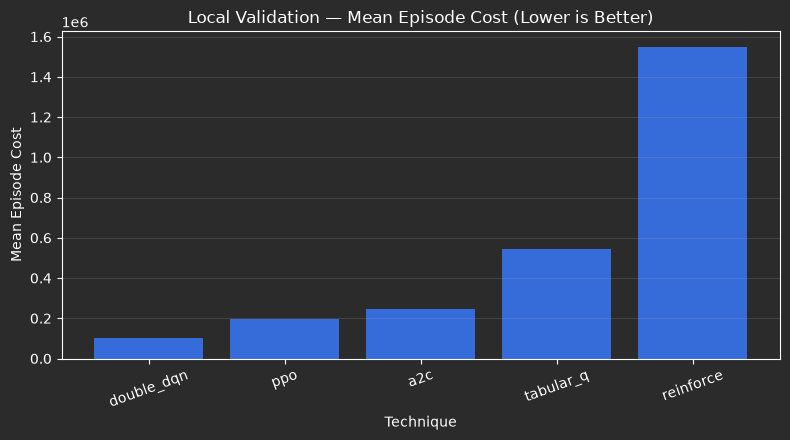

In [16]:

plot_df = overall_summary.sort_values("mean")

plt.figure(figsize=(8, 4.5))
plt.bar(plot_df.index, plot_df["mean"])
plt.ylabel("Mean Episode Cost")
plt.xlabel("Technique")
plt.title("Local Validation — Mean Episode Cost (Lower is Better)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()



## 16. Final validation results used in the report

The following values come from the final 250 held-out validation episodes supplied for this project run (5 techniques × 5 scenario families × 10 seeds).


In [17]:

final_summary = pd.DataFrame({
    "technique": ["double_dqn", "ppo", "a2c", "tabular_q", "reinforce"],
    "mean_cost": [97134.15, 194605.40, 241688.80, 788377.80, 1063956.40],
})

display(final_summary)

final_scenario_summary = pd.DataFrame({
    "technique": ["double_dqn", "ppo", "a2c", "tabular_q", "reinforce"],
    "stationary": [97066.25, 191220.00, 228052.00, 794983.00, 1073630.75],
    "seasonal": [94747.00, 188040.50, 231563.25, 832597.50, 1079060.00],
    "trend": [90436.50, 192553.50, 240451.75, 840821.25, 1055480.50],
    "shock": [99496.25, 199014.50, 248990.75, 711944.75, 1054453.25],
    "mixed": [104124.75, 202198.50, 259386.25, 761542.50, 1057157.75],
}).set_index("technique")

display(final_scenario_summary.round(2))


,technique,mean_cost
0,double_dqn,97134.15
1,ppo,194605.40
2,a2c,241688.80
3,tabular_q,788377.80
4,reinforce,1063956.40


,stationary,seasonal,trend,shock,mixed
technique,,,,,
double_dqn,97066.25,94747.00,90436.50,99496.25,104124.75
ppo,191220.00,188040.50,192553.50,199014.50,202198.50
a2c,228052.00,231563.25,240451.75,248990.75,259386.25
tabular_q,794983.00,832597.50,840821.25,711944.75,761542.50
reinforce,1073630.75,1079060.00,1055480.50,1054453.25,1057157.75



## 17. Build final submission folder which has ZIP of following files

Each leaderboard submission should contain:

1. exactly one frozen `policy_*.py` renamed as `policy.py` file implementing `run_policy(observation)`;
2. the corresponding trained model artefact used by that policy.
